## Importing Packages

In [549]:
import pandas as pd
import numpy as np
import polars as pl
import glob

from tvDatafeed import TvDatafeed, Interval
import pandas_ta as ta
from backtesting import Backtest, Strategy

import matplotlib.pyplot as plt

import os
import traceback
from datetime import date

## Creating the Dataset

### Downloading NIFTY 500 data (index constituents downloaded from NSE website on 16th November)

In [550]:
# csv file downloaded from NSE website (on 16th November)
data_nifty500 = pl.read_csv('ind_nifty500list.csv')

symbols_nifty500 = data_nifty500['Symbol'].to_list()

# Correcting the mismatch in the usage of - instead of _ in the two different datasets
symbols_nifty500 = [s.replace("-", "_") for s in symbols_nifty500]

# Removing a dummy entry in the dataset that doesnt correspond to any stock
symbols_nifty500.remove('DUMMYSKFIN')

print(f'Total stocks: {len(symbols_nifty500)}')

Total stocks: 501


In [551]:
# Initializing TvDatafeed for data
tv = TvDatafeed()

you are using nologin method, data you access may be limited


In [552]:
failed = []

# Downlaod only when the master file does not already exist (avoids unnecessary downloads each time the notebook is run)
if not os.path.exists("Data/Processed/Prices_all.parquet"):
    for symbol in symbols_nifty500:
        # Downloading 5000 bars (approx 20 years). Will filter later as per requirement
        try:
            df = tv.get_hist(symbol = symbol,
                             exchange = 'NSE',
                             interval = Interval.in_daily,
                             n_bars = 5000)

            # Using Parquet files to speed up computation given the size of the dataset
            df.to_parquet(f"data/raw/prices/{symbol}.parquet")

        except Exception as e:
            failed.append(symbol)


    # TVFeed fails to download the data sometimes. This while loop ensures that all 501 stocks are downloaded properly
    while len(failed) != 0:

        for symbol in failed[:]:
            try:
                df = tv.get_hist(symbol = symbol,
                                 exchange = 'NSE',
                                 interval = Interval.in_daily,
                                 n_bars = 5000)

                df.to_parquet(f"data/raw/prices/{symbol}.parquet")
                failed.remove(symbol)

            except:
                pass

    print("\nFailed cases were run repeatedly until success. Data download is complete.")

else:
    print("Skipping as master file already exists")

Skipping as master file already exists


### Downloading NIFTY 50 index data for benchmarking and market regime filtering

In [553]:
# Downlaod only when the file does not already exist
if not os.path.exists("Data/Raw/NIFTY_50.parquet"):
    # Downloading 5000 bars (approx 20 years). Will filter as per requirement
    index_df = tv.get_hist(symbol = 'NIFTY', exchange = 'NSE', interval = Interval.in_daily, n_bars = 5000)
    index_df.to_parquet("Data/Raw/NIFTY_50.parquet")

else:
    index_df = pd.read_parquet("Data/Raw/NIFTY_50.parquet")
    print("Skipping as NIFTY 50 data already exists")

Skipping as NIFTY 50 data already exists


### Merging individual stock data files into a single master file

In [554]:
raw_directory = "Data/Raw/Prices"
output_file = "Data/Processed/Prices_all.parquet"

def merge_parquet_files():
    # Merging only when the final master file does not already exist
    if os.path.exists(output_file):
        print("Skipping to avoid overwrite as merged data file already exists")
        return

    files = glob.glob(os.path.join(raw_directory, "*.parquet"))

    if len(files) == 0:
        print("No parquet files found in data/raw/prices/")
        return

    dfs = []

    for file in files:
        symbol = os.path.basename(file).replace(".parquet", "")
        df = (pl.read_parquet(file).with_columns([pl.lit(symbol).alias("symbol")]))
        df = df.rename({"datetime": "date"})
        dfs.append(df)

    final_df = pl.concat(dfs, how = "vertical")
    final_df = final_df.sort(["symbol", "date"])
    final_df.write_parquet(output_file)

    print(f"Master file created: {output_file}")
    print(f"\nRows: {final_df.height}, Columns: {final_df.width}")


if __name__ == "__main__":
    merge_parquet_files()

Skipping to avoid overwrite as merged data file already exists


## Loading the Dataset

#### Loading and filtering to start the analysis from 2012 (with an additional 252 day lookback period)

In [555]:
# Starting the analysis from 2011 (to include a lookback period before train start date)
analysis_start_date = pd.Timestamp(2011, 1, 1)

# Train date starts from 1 January, 2012
train_start_date = pd.Timestamp(2012, 1, 1)

# Test date starts from 1 January, 2020
test_start_date = pd.Timestamp(2020, 1, 1)

# Filtering to remove all dates before the analysis start date and sorting by symbol and price to maintain chronology
df = (pl.read_parquet("Data/Processed/Prices_all.parquet")
      .filter(pl.col("date") >= analysis_start_date)
      .sort(["symbol", "date"]))

# Capitalizing the columns to maintain backfeed.py's naming convention
df = df.rename({col: col.capitalize() for col in df.columns})


# NOTE: some stocks might be listed at a later date and therefore might not have data for the entire period
df.head

<bound method DataFrame.head of shape: (1_402_156, 7)
┌───────────┬─────────┬─────────┬─────────┬──────────┬────────────┬─────────────────────┐
│ Symbol    ┆ Open    ┆ High    ┆ Low     ┆ Close    ┆ Volume     ┆ Date                │
│ ---       ┆ ---     ┆ ---     ┆ ---     ┆ ---      ┆ ---        ┆ ---                 │
│ str       ┆ f64     ┆ f64     ┆ f64     ┆ f64      ┆ f64        ┆ datetime[ns]        │
╞═══════════╪═════════╪═════════╪═════════╪══════════╪════════════╪═════════════════════╡
│ 360ONE    ┆ 302.5   ┆ 317.625 ┆ 302.5   ┆ 317.625  ┆ 7.10986e6  ┆ 2019-09-19 09:15:00 │
│ 360ONE    ┆ 332.25  ┆ 333.5   ┆ 332.25  ┆ 333.5    ┆ 2.760648e6 ┆ 2019-09-20 09:15:00 │
│ 360ONE    ┆ 350.175 ┆ 350.175 ┆ 350.175 ┆ 350.175  ┆ 34096.0    ┆ 2019-09-23 09:15:00 │
│ 360ONE    ┆ 367.675 ┆ 367.675 ┆ 367.675 ┆ 367.675  ┆ 2.496652e6 ┆ 2019-09-24 09:15:00 │
│ 360ONE    ┆ 386.05  ┆ 386.05  ┆ 349.3   ┆ 351.2375 ┆ 530580.0   ┆ 2019-09-25 09:15:00 │
│ …         ┆ …       ┆ …       ┆ …       ┆ … 

In [556]:
# Doing the same preprocessing for NIFTY 50 index
index_df = (index_df
            .reset_index()
            .rename(columns = lambda c: c.capitalize())
            .rename(columns={"Datetime": "Date"})
            .assign(Date = lambda df: pd.to_datetime(df["Date"]))
            .loc[lambda df: df["Date"] >= analysis_start_date]
            .sort_values("Date")
            .set_index("Date"))

print("The dimensions of the dataframe:", index_df.shape)
index_df.head()

The dimensions of the dataframe: (3686, 6)


,Symbol,Open,High,Low,Close,Volume
Date,,,,,,
2011-01-03 09:15:00,NSE:NIFTY,6177.4502,6178.5498,6147.2002,6157.6001,96029000.0
2011-01-04 09:15:00,NSE:NIFTY,6172.7500,6181.0498,6124.3999,6146.3501,181728002.0
2011-01-05 09:15:00,NSE:NIFTY,6141.3501,6141.3501,6062.3501,6079.7998,139613995.0
2011-01-06 09:15:00,NSE:NIFTY,6107.0000,6116.1499,6022.2998,6048.2500,152339005.0
2011-01-07 09:15:00,NSE:NIFTY,6030.8999,6051.2002,5883.6001,5904.6001,171808997.0


## Calculating the Technical Indicators

### A. Setting up the indicators as functions for reuse

#### 1) Moving Average Convergence Divergence (MACD)

In [557]:
def MACD(close, fast, slow, signal):
    MACD = ta.macd(close = close, fast = fast, slow = slow, signal = signal)
    
    return MACD[f"MACD_{fast}_{slow}_{signal}"]

#### 2) MACD Signal

In [558]:
def MACD_Signal(close, fast, slow, signal):
    MACD_signal = ta.macd(close = close, fast = fast, slow = slow, signal = signal)
    
    return MACD_signal[f"MACDs_{fast}_{slow}_{signal}"]

#### 3) Volume-weighted Average Price (VWAP)

In [559]:
def VWAP(high, low, close, volume, length):
    VWAP_20 = ta.vwap(high = high, low = low, close = close, volume = volume, length = length)
    
    return VWAP_20

#### 4) Rate of Change (ROC)

In [560]:
def ROC(close, length):
    ROC = ta.roc(close = close, length = length)
    
    return ROC

#### 5) Exponential Moving Average (EMA)

In [561]:
def EMA(close, length):
    EMA = ta.ema(close, length = length)
    
    return EMA

#### 6) Relative Strength Index (RSI)

In [562]:
def RSI(close, length):
    RSI = ta.rsi(close = close, length = length)
    
    return RSI

#### 7) Average Directional Movement Index (ADX)

In [563]:
def ADX(high, low, close, length):
    ADX = ta.adx(high = high, low = low, close = close, length = length)
    
    return ADX[f"ADX_{length}"]

#### 8) Moving Average (MA)

In [564]:
def MA(variable, length):
    ma = ta.sma(close = variable, length = length)
    
    return pd.to_numeric(ma, errors = "coerce")

#### 9) Average True Range (ATR)

In [565]:
def ATR(high, low, close, length):
    ATR = ta.atr(high = high, low = low, close = close, length = length)
    
    return ATR

#### 10) Volatility

In [566]:
def Volatility(close, length):
    Volatility = ta.stdev(close = close, length = length)
    
    return Volatility

#### 11) Keltner

In [567]:
def Keltner(high, low, close, length, k):
    Keltner_middle = EMA(close = close, length = length)

    ATR_value = ATR(high = high, low = low, close = close, length = length)
    
    Keltner_upper = EMA(close, length = length) + (k * ATR_value)
    Keltner_lower = EMA(close, length = length) - (k * ATR_value)

    return Keltner_upper.values, Keltner_middle.values, Keltner_lower.values

#### 12) Range Expansion

In [568]:
def range_expansion(high, low, close, open, atr_length):
    Range_expansion = (close - open)/ ATR(high = high, low = low, close = close, length = atr_length)
    
    return Range_expansion

#### 13) Volume Z-Score

In [569]:
def Volume_Z(volume, length):
     Volume_Z = (volume - MA(variable = volume, length = length))/ Volatility(close = volume, length = length)
     
     return Volume_Z

#### 14) Trend Noise Ratio

In [570]:
def Trend_noise_ratio(high, low, close):
    ATR_14 = ATR(high = high, low = low, close = close, length = 14)
    MA_50 = MA(variable = close, length = 50)
    MA_200 = MA(variable = close, length = 200)

    difference = (MA_50 - MA_200).abs()
    difference = difference.replace(0, np.nan)

    Trend_Noise_Ratio = ATR_14/ difference
    Trend_Noise_Ratio = Trend_Noise_Ratio.replace([np.inf, -np.inf], np.nan)

    return Trend_Noise_Ratio

#### 15) Gap

In [571]:
def Gap(open, close):
    GAP = open - close.shift(1).abs()/ close.shift(1)
    
    return GAP

#### 16) Breadth

In [572]:
def row_breadth(df_dict):
    symbols = list(df_dict.keys())
    dates = df_dict[symbols[0]].index

    ma_dict = {}
    
    for symbol in symbols:
        df = df_dict[symbol].copy()
        df["MA-Price_50"] = MA(df["Close"], length = 50)
        df = df.dropna(subset = ["MA-Price_50"]) 
        ma_dict[symbol] = df
    

    breadth_list = []

    for date in dates:
        count = 0
        total = 0

        for symbol in symbols:
            df = ma_dict[symbol]

            if date not in df.index:
                continue

            row = df.loc[date]

            MA_50 = row["MA-Price_50"]
            close = row["Close"]

            total += 1
            if close > MA_50:
                count += 1

        breadth_list.append(count / total if total > 0 else np.nan)

    return pd.DataFrame({"Breadth": breadth_list}, index = dates)

### B. Computing the indicators and adding them as columns to the data frame

In [573]:
def compute_indicators(df):
    
    df = df.copy()

    # OHLCV values stored as a series for passing into pandas technical analysis functions
    o = df["Open"]
    h = df["High"]
    l  = df["Low"]
    c = df["Close"]
    v = df["Volume"]

    # Computing the technical indicators using the functions defined before
    df["ATR_14"]   = ATR(high = h, low = l, close = c, length = 14)

    df["RSI"]   = RSI(close = c, length = 5)

    df["ADX"]   = ADX(high = h, low = l, close = c, length = 14)

    df["ROC"] = ROC(close = c, length = 20)

    df["EMA_20"] = EMA(close = c, length = 20)
    df["EMA_50"] = EMA(close = c, length = 50)
    df["EMA_200"] = EMA(close = c, length = 200)

    df["MACD"]  = MACD(close = c, fast = 12, slow = 26, signal = 9)
    df["MACD_signal"]  = MACD_Signal(close = c, fast = 12, slow = 26, signal = 9)

    df["VWAP"]  = VWAP(high = h, low = l , close = c, volume = v, length = 5)

    df["Volatility"] = Volatility(close = c, length = 20)
    
    df["Trend_noise_ratio"] = Trend_noise_ratio(high = h, low = l, close = c)

    df["Keltner_upper"] = Keltner(high = h, low = l, close = c, length = 20, k = 1.5)[0]
    df["Keltner_middle"] = Keltner(high = h, low = l, close = c, length = 20, k = 1.5)[1]
    df["Keltner_lower"] = Keltner(high = h, low =l, close = c, length = 20, k = 1.5)[2]

    df['Range_expansion'] = range_expansion(high = h, low = l, close = c, open = o, atr_length = 14)

    df['Volume_z'] = Volume_Z(volume = v, length = 20)

    df["Gap"] = Gap(open = o, close = c)

    df["MA-Volume_10"]  = MA(variable = v, length = 10)    
    df["MA-Volume_20"]  = MA(variable = v, length = 20)

    df["MA-Price_20"]  = MA(variable = c, length = 20)
    df["MA-Price_50"]  = MA(variable = c, length = 50)
    df["MA-Price_100"] = MA(variable = c, length = 100)
    df["MA-Price_200"] = MA(variable = c, length = 200)

    return df

## Defining the Strategies

### 1) Strategy Definition - Low Strategy

In [574]:
class Low_Strategy(Strategy):
    # Initializing a direction filter that forces either short/ long trades based on the market regime
    direction = "both"

    # Hyperparameters in the strategy for fine tuning
    tp_atr = 3
    sl_atr = 2

    sl_percentage = 0.05
    risk_per_trade = 0.06

    keltner_k = 1.5




    def init(self):
        # Setting up the High, Low, Close and Open values as attributes
        h = pd.Series(self.data.High, index = self.data.index)
        l = pd.Series(self.data.Low, index = self.data.index)
        c = pd.Series(self.data.Close, index = self.data.index)
        o = pd.Series(self.data.Open, index = self.data.index)

        # Computing the required indicators and setting them up as attributes
        self.keltner_upper, self.keltner_middle, self.keltner_lower = self.I(Keltner, high = h, low = l, close = c, length = 20, k = self.keltner_k)
        self.range_expansion  = self.I(range_expansion, high = h, low = l, close = c, open = o, atr_length = 20)
        self.ema_50 = self.I(EMA, close = c, length = 50)
        self.ema_200 = self.I(EMA, close = c, length = 200)
        self.atr  = self.I(ATR, high = h, low = l, close = c, length = 14)

        # Initializing Entry Price and Stop Loss as attributes
        self.entry_price = None
        self.current_stop_loss  = None




    # Sizing short/ long position based on the strategy's risk tolerance
    def calc_position_size(self, atr_now, price_now):
        equity = self.equity
        risk_capital = equity * self.risk_per_trade
        per_share_risk = self.sl_atr * atr_now

        raw_size = risk_capital // per_share_risk
        max_affordable = equity // price_now

        # Do not allow trades more than capital availability
        size = int(min(raw_size, max_affordable))

        return max(size, 1)
    



    def next(self):
        # Extracting indicators for the relevant time period for signal generation/ validation/ filtering
        price_now = self.data.Close[-1]
        keltner_upper_now = self.keltner_upper[-1]
        keltner_middle_now = self.keltner_middle[-1]
        keltner_lower_now = self.keltner_lower[-1]
        range_expansion_now = self.range_expansion[-1]
        atr_now = self.atr[-1]


        # Exit Logic (defined for long. Short positions will be the opposite)
        # Signal breaks - Price falls below keltner middle value
        # Profit booking - Price exceeds entry + (3 * ATR)
        # Stop Loss - Price falls below entry - (2 * ATR)
        if self.position:

            # Keltner middle value is crossed. Exit Position as it goes against the strategy's logic
            exit = (self.position.is_long and (price_now < (keltner_middle_now))) or \
                   (self.position.is_short and (price_now > (keltner_middle_now)))

            
            # Price > entry + (3 * ATR). Book profits and exit (similarly for short position)
            exit_tp = (self.position.is_long and price_now >= self.entry_price + (self.tp_atr * atr_now)) or \
                      (self.position.is_short and price_now <= self.entry_price - (self.tp_atr * atr_now))


            # Price < entry - (2 * ATR). Stop losses and exit (similarly for short position)
            if self.position.is_long:
                new_stop_loss = price_now - (self.sl_atr * atr_now)
                
                if self.current_stop_loss is None:
                    self.current_stop_loss = new_stop_loss
                
                else:
                    # Updating stop loss parameter based on stock's movements
                    self.current_stop_loss = max(self.current_stop_loss, new_stop_loss)

                # Checking if the stop loss threshold is breached
                exit_sl = (price_now <= self.current_stop_loss)

            else:
                new_stop_loss = price_now + (self.sl_atr * atr_now)

                if self.current_stop_loss is None:
                    self.current_stop_loss = new_stop_loss
                
                else:
                    # Updating stop loss parameter based on stock's movements
                    self.current_stop_loss = min(self.current_stop_loss, new_stop_loss)

                # Checking if the stop loss threshold is breached
                exit_sl = (price_now >= self.current_stop_loss)


            # Exit position if signal breaks, profit booking opportunity arises or stop loss threshold is breached
            if exit or exit_tp or exit_sl:
                self.position.close()
                self.entry_price = None
                self.current_stop_loss  = None

            return


        # Entry Logic (defined for long. Short positions will be the opposite)
        # Signal Generation - Price exceeds the keltner upper bound
        # Signal Validation - Range of the stock is widening
        long_signal = (price_now > keltner_upper_now and range_expansion_now >= 1.15)
        short_signal = (price_now < keltner_lower_now and range_expansion_now >= 1.15)


        # Sizing the position based on risk as per ATR (defined in the function)
        size = self.calc_position_size(atr_now = atr_now, price_now = price_now)


        # Force trade type (long/ short) based on market regime
        if self.direction == "long":
            short_signal = False

        if self.direction == "short":
            long_signal = False


        # Enter Long or Short with the stop loss, take profit and size parameters defined above
        if long_signal:
            sl = price_now - (self.sl_atr * atr_now)
            tp = price_now + (self.tp_atr * atr_now)

            self.buy(sl = sl, tp = tp, size = size)

            self.entry_price = price_now
            self.current_stop_loss  = sl

        elif short_signal:
            sl = price_now + (self.sl_atr * atr_now)
            tp = price_now - (self.tp_atr * atr_now)

            self.sell(sl = sl, tp = tp, size = size)

            self.entry_price = price_now
            self.current_stop_loss  = sl


print("Low Strategy class successfully defined")

Low Strategy class successfully defined


### 2) Strategy Definition - Medium Strategy

In [575]:
class Medium_Strategy(Strategy):
    # Initializing a direction filter that allows strategies to take only long or short positions based on the market regime
    direction = "both"

    # Hyperparameters in the strategy for fine tuning
    risk_per_trade = 0.04

    tp_atr = 3
    sl_atr = 2




    def init(self):
        # Setting up the High, Low and Close values as attributes
        h = pd.Series(self.data.High, index = self.data.index)
        l = pd.Series(self.data.Low, index = self.data.index)
        c = pd.Series(self.data.Close, index = self.data.index)

        # Computing the required indicators and setting them up as attributes
        self.macd = self.I(MACD, close = c, fast = 12, slow = 26, signal = 9)
        self.roc  = self.I(ROC, close = c, length = 14)
        self.adx  = self.I(ADX, high = h, low = l, close = c, length = 14)
        self.atr  = self.I(ATR, high = h, low = l, close = c, length = 14)

        # Initializing Entry Price and Stop Loss as attributes
        self.entry_price = None
        self.current_stop_loss  = None




    # Sizing short/ long position based on the strategy's risk tolerance
    def calc_position_size(self, atr_now, price_now):
        equity = self.equity
        risk_capital = equity * self.risk_per_trade
        per_share_risk = self.sl_atr * atr_now

        raw_size = risk_capital // per_share_risk
        max_affordable = equity // price_now

        # Do not allow trades more than capital availability
        size = int(min(raw_size, max_affordable))

        return max(size, 1)
    



    def next(self):
        # Extracting indicators for the relevant time period for signal generation/ validation/ filtering
        price_now = self.data.Close[-1]
        atr_now = self.atr[-1]
        macd_now = self.macd[-1]
        roc_now = self.roc[-1]
        adx_now = self.adx[-1]


        # Exit Logic (defined for long. Short positions will be the opposite)
        # Signal breaks - MACD reverses 
        # Profit booking -  price exceeds entry + (3 * ATR)
        # Stop Loss - Price falls below entry - (2 * ATR)
        if self.position:

            # MACD trend reverses. Exit Position as it goes against the strategy's logic
            exit = (self.position.is_long and macd_now < 0) or \
                   (self.position.is_short and macd_now > 0)

            
            # Price > entry + (3 * ATR). Book profits and exit (similarly for short position)
            exit_tp = (self.position.is_long and price_now >= self.entry_price + (self.tp_atr * atr_now)) or \
                      (self.position.is_short and price_now <= self.entry_price - (self.tp_atr * atr_now))


            # Price < entry - (2 * ATR). Stop losses and exit (similarly for short position)
            if self.position.is_long:
                new_stop_loss = price_now - (self.sl_atr * atr_now)
                
                if self.current_stop_loss is None:
                    self.current_stop_loss = new_stop_loss
                
                else:
                    # Updating stop loss parameter based on stock's movements
                    self.current_stop_loss = max(self.current_stop_loss, new_stop_loss)

                # Checking if the stop loss threshold is breached
                exit_sl = (price_now <= self.current_stop_loss)

            else:
                new_stop_loss = price_now + (self.sl_atr * atr_now)

                if self.current_stop_loss is None:
                    self.current_stop_loss = new_stop_loss
                
                else:
                    # Updating stop loss parameter based on stock's movements
                    self.current_stop_loss = min(self.current_stop_loss, new_stop_loss)

                # Checking if the stop loss threshold is breached
                exit_sl = (price_now >= self.current_stop_loss)

            # Exit position if signal breaks, profit booking opportunity arises or stop loss threshold is breached
            if exit or exit_tp or exit_sl:
                self.position.close()
                self.entry_price = None
                self.current_stop_loss  = None

            return


        # Entry Logic (defined for long. Short positions will be the opposite)
        # Signal Generation - MACD > 0 shows that a trend is beginning
        # Signal Validation - ROC ensures consistency in the trend (avoids noise)
        # Signal Filtering - ADX shows momentum and profit opportunity (avoids noise)
        long_signal = (macd_now > 0 and roc_now > 0 and adx_now > 25)
        short_signal = (macd_now < 0 and roc_now < 0 and adx_now > 25)


        # Sizing the position based on risk as per ATR (defined in the function)
        size = self.calc_position_size(atr_now = atr_now, price_now = price_now)


        # Force trade type (long/ short) based on market regime
        if self.direction == "long":
            short_signal = False

        if self.direction == "short":
            long_signal = False


        # Enter Long or Short with the stop loss, take profit and size parameters defined above
        if long_signal:
            sl = price_now - (self.sl_atr * atr_now)
            tp = price_now + (self.tp_atr * atr_now)

            self.buy(sl = sl, tp = tp, size = size)

            self.entry_price = price_now
            self.current_stop_loss  = sl

        elif short_signal:
            sl = price_now + (self.sl_atr * atr_now)
            tp = price_now - (self.tp_atr * atr_now)

            self.sell(sl = sl, tp = tp, size = size)

            self.entry_price = price_now
            self.current_stop_loss  = sl
    

print("Medium Strategy class successfully defined")

Medium Strategy class successfully defined


### 3) Strategy Definition - High Strategy

In [576]:
class High_Strategy(Strategy):
    
    # Initializing a direction filter that allows strategies to take only long or short positions based on the market regime
    direction = "both"

    # Hyperparameters in the strategy for fine tuning
    vwap_deviation = 0.025

    risk_per_trade = 0.075

    sl_percentage = 0.10
    tp_percentage = 0.10

    tp_atr = 3
    sl_atr = 2



    def init(self):
        # Setting up the High, Low, Close and Volume values as attributes
        h = pd.Series(self.data.High, index = self.data.index)
        l = pd.Series(self.data.Low, index = self.data.index)
        c = pd.Series(self.data.Close, index = self.data.index)
        v = pd.Series(self.data.Volume, index = self.data.index)

        # Computing the required indicators and setting them up as attributes
        self.vwap = self.I(VWAP, high = h, low = l, close = c, volume = v, length = 20)
        self.rsi  = self.I(RSI, close = c, length = 5)
        self.sma_volume  = self.I(MA, variable = v, length = 20)
        self.adx = self.I(ADX, high = h, low = l, close = c, length = 14)
        self.atr  = self.I(ATR, high = h, low = l, close = c, length = 14)

        # Initializing Entry Price and Stop Loss as attributes
        self.entry_price = None
        self.current_sl  = None




    # Sizing short/ long position based on the strategy's risk tolerance
    def calc_position_size(self, atr_now, price_now):
        equity = self.equity
        risk_capital = equity * self.risk_per_trade
        per_share_risk = self.sl_atr * atr_now

        raw_size = risk_capital // per_share_risk
        max_affordable = equity // price_now

        # Do not allow trades more than capital availability
        size = int(min(raw_size, max_affordable))

        return max(size, 1)




    def next(self):
        # Extracting indicators for the relevant time period for signal generation/ validation/ filtering
        price_now = self.data.Close[-1]
        vwap_now = self.vwap[-1]
        rsi_now = self.rsi[-1]
        atr_now = self.atr[-1]


        # Exit Logic (defined for long. Short positions will be the opposite)
        # Signal breaks - RSI shows an opposing pattern
        # Profit booking -  price exceeds entry + (3 * ATR)
        # Stop Loss - Price falls below entry - (2 * ATR)    
        if self.position:

            # Exit Logic 1 - When RSI is no longer indicating oversold/ overbought
            exit = (self.position.is_long and rsi_now > 70) or \
                   (self.position.is_short and rsi_now < 30)
            

            # Price > entry + (3 * ATR). Book profits and exit (similarly for short position)
            exit_tp = (self.position.is_long and price_now >= self.entry_price + (self.sl_atr * atr_now)) or \
                      (self.position.is_short and price_now <= self.entry_price - (self.tp_atr * atr_now))


            # Price < entry - (2 * ATR). Stop losses and exit (similarly for short position)
            if self.position.is_long:
                new_stop_loss = price_now - (self.sl_atr * atr_now)
                
                if self.current_stop_loss is None:
                    self.current_stop_loss = new_stop_loss
                
                else:
                    # Updating stop loss parameter based on stock's movements
                    self.current_stop_loss = max(self.current_stop_loss, new_stop_loss)

                # Checking if the stop loss threshold is breached
                exit_sl = (price_now <= self.current_stop_loss)

            else:
                new_stop_loss = price_now + (self.sl_atr * atr_now)

                if self.current_stop_loss is None:
                    self.current_stop_loss = new_stop_loss
                
                else:
                    # Updating stop loss parameter based on stock's movements
                    self.current_stop_loss = min(self.current_stop_loss, new_stop_loss)

                # Checking if the stop loss threshold is breached
                exit_sl = (price_now >= self.current_stop_loss)
            

            # Exit position if signal breaks, profit booking opportunity arises or stop loss threshold is breached
            if exit or exit_tp or exit_sl:
                self.position.close()
                self.entry_price = None
                self.current_sl  = None
                
            return


        # Entry Logic (defined for long. Short positions will be the opposite)
        # Signal Generation - Price < 20-day vwap (with some relaxation)
        # Signal Validation - RSI ensures that the stock is heavily oversold (overbought), creating a mean reversion setup
        long_signal = ((price_now < (vwap_now * (1 + self.vwap_deviation))) and 
                       (rsi_now < 30))
        
        short_signal = ((price_now > vwap_now * ((1 - self.vwap_deviation))) and 
                       (rsi_now > 70))


        # Sizing the position based on risk as per ATR (defined in the function)
        size = self.calc_position_size(atr_now = atr_now, price_now = price_now)
        

        # Enter Long or Short with the stop loss, take profit and size parameters defined above
        if self.direction == "long":
            short_signal = False

        if self.direction == "short":
            long_signal = False


        # Enter Long or Short with the stop loss, take profit and size parameters defined above
        if long_signal:
            sl = price_now - (self.sl_atr * atr_now)
            tp = price_now + (self.tp_atr * atr_now)

            self.buy(sl = sl, tp = tp, size = size)

            self.entry_price = price_now
            self.current_stop_loss  = sl

        elif short_signal:
            sl = price_now + (self.sl_atr * atr_now)
            tp = price_now - (self.tp_atr * atr_now)

            self.sell(sl = sl, tp = tp, size = size)

            self.entry_price = price_now
            self.current_stop_loss  = sl
    

print("High Strategy class successfully defined")

High Strategy class successfully defined


## Stock selection

### A. Filtering the universe to avoid illiquid and highly volatile stocks

In [577]:
def filter_universe(df_dict):
    filtered_stocks = []

    for symbol, df in df_dict.items():
        # Computing the turnover (value traded)
        df["Turnover"] = df["Close"] * df["Volume"]

        # Removing illiquid stocks - reject if 20-day average trade value is under rupees 10 crore
        if df["Turnover"].rolling(20).mean().iloc[-1] < 10_00_00_000:
            continue

        # Removing stocks with a low price (generally highly volatile stocks) - reject if price is less than 10
        if df["Close"].rolling(20).mean().iloc[-1] < 10:
            continue

        # Sometimes turnover is high due to high price - reject if 20-day average volume less than 50 thousand 
        if df["Volume"].rolling(20).mean().iloc[-1] < 50_000:
            continue

        # Removing highly volatile stocks - reject if 20-day standard deviation of returns exceeds 7%
        if df["Close"].pct_change().rolling(20).std().iloc[-1] > 0.07:
            continue
        
        # Retain only those stocks that pass all these filters
        filtered_stocks.append(symbol)

    return filtered_stocks

### B.1) Selecting stocks from the filtered universe - Low Strategy

In [578]:
def low_select_stocks(df_dict, lookback):
    rows = []
    for symbol, df in df_dict.items():
        try:
            # Computing all the necessary indicators
            df_with_indicators = compute_indicators(df)

            # If the df is empty or if the df has fewer trading days than the lookback perdod, move to the next stock
            if (df_with_indicators is None) or (len(df_with_indicators) < lookback):
                continue

            data = df_with_indicators.iloc[-1]


            close = data["Close"]

            keltner_upper = data["Keltner_upper"]
            keltner_middle = data["Keltner_middle"]
            keltner_lower = data["Keltner_lower"]

            atr = data["ATR_14"]
            range_expansion = data["Range_expansion"]
            ema_50 = data["EMA_50"]
            ema_200 = data["EMA_200"]


            # Checking the trend based on EMA 50 and 200 comparison
            trend_long  = 1 if (ema_50 > ema_200) else 0
            trend_short = 1 if (ema_50 < ema_200) else 0


            # Checking the extend to which price is above the keltner upper bound (using the middle value as reference)
            if (keltner_upper - keltner_middle) != 0:
                pressure_long = (close - keltner_middle) / (keltner_upper - keltner_middle)

            else:
                pressure_long = 0


            # Checking the extend to which price is below the keltner lower bound (using the middle value as reference)
            if (keltner_middle - keltner_lower) != 0:
                pressure_short = (keltner_middle - close) / (keltner_middle - keltner_lower)

            else:
                pressure_short = 0


            # Range expansion pre-signal (normalized toward breakout)
            range_expansion_normalized = min((range_expansion / 1.5), 1.0)


            # Volatility normalization
            atr_norm = atr / max(close, 1e-9)
            volatility_score = 1 / (atr_norm + 1e-9)


            # Calculating the weighted long and short scores
            long_score  = (2.0 * trend_long +
                           2.0 * pressure_long +
                           1.5 * range_expansion_normalized +
                           1.5 * volatility_score)

            short_score = (2.0 * trend_short +
                           2.0 * pressure_short +
                           1.5 * range_expansion_normalized +
                           1.5 * volatility_score)


            # Assessing the direction which shows the strongest pattern which becomes the overall score
            if long_score >= short_score:
                score = long_score
                direction = "long"

            else:
                score = short_score
                direction = "short"

            # Compiling the symbol along with the best score and direction
            rows.append({"Symbol": symbol,
                         "Score": score,
                         "Direction": direction})

        except Exception as e:
            print(f"Error in {symbol}: {e}")
            continue

    # Safeguarding against empty selections
    if not rows:
        return []

    df = pd.DataFrame(rows)
    df = df.sort_values("Score", ascending = False)

    # Return the top 20 stocks along with their best direction
    return list(zip(df["Symbol"].head(20), df["Direction"].head(20)))

### B.2) Selecting stocks from the filtered universe - Medium Strategy

In [579]:
def medium_select_stocks(df_dict, lookback):
    rows = []

    for symbol, df in df_dict.items():
        try:
            # Computing all the necessary indicators
            df_with_indicators = compute_indicators(df)
        
            # If the df is empty or if the df has fewer trading days than the lookback perdod, move to the next stock
            if df_with_indicators is None or len(df_with_indicators) < lookback:
                continue

            data = df_with_indicators.tail(lookback)

            # If the df has fewer trading days than the lookback perdod, move to the next stock
            if len(data) < lookback:
                continue

            # Assessing trend structures since this is a trend and momentum based strategy
            up_trend   = ((data["MA-Price_20"] > data["MA-Price_50"]) &
                          (data["MA-Price_50"] > data["MA-Price_100"])).mean()

            down_trend = ((data["MA-Price_20"] < data["MA-Price_50"]) &
                          (data["MA-Price_50"] < data["MA-Price_100"])).mean()

            slope_50  = data["MA-Price_50"].diff().mean()
            slope_200 = data["MA-Price_200"].diff().mean()

            # Assessing the momentum as this is a trend and momentum based strategy
            roc_up   = (data["ROC"] > 0).mean()
            roc_down = (data["ROC"] < 0).mean()

            macd_up   = (data["MACD"] > 0).mean()
            macd_down = (data["MACD"] < 0).mean()

            macd_trend_quality = (data["MACD"] > data["MACD_signal"]).mean()

            adx_strength = (data["ADX"] > 20).mean()

            # Checking whether it is noise or breakout
            noise = (data["ATR_14"] / (data["Close"].diff().abs() + 1e-9)).mean()

            breakout = (data["Close"] > data["Close"].rolling(50).max().shift(1)).mean()


            turnover = (data["Close"] * data["Volume"]).rolling(20).mean().iloc[-1]

            # Append all the raw features into a single dataset
            rows.append({"Symbol": symbol,
                         "Date": df_with_indicators.index[-1],

                        "Up_trend": up_trend,
                        "Down_trend": down_trend,
                        "Slope_50": slope_50,
                        "Slope_200": slope_200,

                        "ROC_up": roc_up,
                        "ROC_down": roc_down,

                        "MACD_up": macd_up,
                        "MACD_down": macd_down,
                        "MACD_trend_quality": macd_trend_quality,

                        "ADX_strength": adx_strength,

                        "Noise": noise,
                        "Breakout": breakout,
                        "Turnover": turnover})

        except Exception as e:
            print(f"Error in {symbol}: {e}")
            continue

    # Safeguarding against empty selections
    if not rows:
        return []


    df = pd.DataFrame(rows)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").sort_index()

    # Standardize across all symbols for the given date
    feature_cols = [c for c in df.columns if c not in ["Symbol"]]

    for col in feature_cols:
        df[col + "_z"] = df.groupby(df.index)[col].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-9))

    # Calculating the weighted long and short scores
    df["Long_score"] = (0.35 * df["Up_trend_z"] +
                        0.25 * df["ROC_up_z"] +
                        0.25 * df["MACD_up_z"] - # Noise should be subtracted
                        0.20 * df["Noise_z"] +
                        0.15 * df["Slope_50_z"] +
                        0.10 * df["Breakout_z"] +
                        0.10 * df["ADX_strength_z"] + 
                        0.10 * df["Turnover_z"])

    df["Short_score"] = (0.35 * df["Down_trend_z"] +
                        0.25 * df["ROC_down_z"] +
                        0.25 * df["MACD_down_z"] - # Noise should be subtracted
                        0.20 * df["Noise_z"] + 
                        0.15 * df["Slope_50_z"] +
                        0.10 * df["ADX_strength_z"] +
                        0.10 * df["Turnover_z"])

    # Assessing the direction which shows the strongest pattern which becomes the overall score
    df["Index_Score"] = df[["Long_score", "Short_score"]].max(axis = 1)
    df["Direction"]   = np.where(df["Long_score"] >= df["Short_score"], 
                                "long", 
                                "short")

    # Return the top 20 stocks along with their best direction
    final_date = df.index.max()
    df_last = df.loc[[final_date]].sort_values("Index_Score", ascending = False)

    return list(zip(df_last["Symbol"].head(20), df_last["Direction"].head(20)))


### B.3) Selecting stocks from the filtered universe - Medium Strategy

In [580]:
def high_select_stocks(df_dict, lookback):
    rows = []

    for symbol, df in df_dict.items():
        try:
            # Computing all the necessary indicators
            df_with_indicators = compute_indicators(df)

            # If the df is empty or if the df has fewer trading days than the lookback perdod, move to the next stock
            if df_with_indicators is None or len(df_with_indicators) < lookback:
                continue

            data = df_with_indicators.tail(10).copy()


            # Checking the 2-day consistency in vwap trend
            vwap_up_2_days = ((data["VWAP"].iloc[-1] > data["Close"].iloc[-1]) and
                              (data["VWAP"].iloc[-2] > data["Close"].iloc[-2]))

            vwap_down_2_days = ((data["VWAP"].iloc[-1] < data["Close"].iloc[-1]) and 
                                (data["VWAP"].iloc[-2] < data["Close"].iloc[-2]))


            # Checking the pickup in volume traded
            volume_ratio = data["Volume"].iloc[-1] / (data["MA-Volume_10"].iloc[-1] + 1e-9)


            # Checking in the 2-day consistency in rsi movement
            rsi_now = data["RSI"].iloc[-1]
            rsi_up = (rsi_now > data["RSI"].iloc[-2] > data["RSI"].iloc[-3])
            rsi_down = (rsi_now < data["RSI"].iloc[-2] < data["RSI"].iloc[-3])

            # Calculating the weighted long and short scores
            long_score = ((1.0 if vwap_up_2_days else 0) +
                          (1.0 if (rsi_now < 60 and rsi_up) else 0) +
                          volume_ratio)

            # Short Score
            short_score = ((1.0 if vwap_down_2_days else 0) +
                           (1.0 if (rsi_now > 40 and rsi_down) else 0) -
                           volume_ratio)

            # Assessing the direction which shows the strongest pattern which becomes the overall score
            score = max(long_score, short_score)
            direction = "long" if long_score >= short_score else "short"

            # Compiling the symbol along with the best score and direction
            rows.append({"Symbol": symbol,
                         "Score": score,
                         "Direction": direction})

        except Exception as e:
            print(f"Error in {symbol}: {e}")
            continue

    # Safeguarding against empty selections
    if not rows:
        return []

    df = pd.DataFrame(rows)
    df = df.sort_values("Score", ascending = False)

    # Return the top 20 stocks along with their best direction
    return list(zip(df["Symbol"].head(20), df["Direction"].head(20)))

## Market Regime Filter

### A. Computing the technical indicators of the index (NIFTY 50)

In [581]:
def compute_regime_indicators(index_df):
    # HLV values of NIFTY 50 index
    high = index_df['High']
    low = index_df['Low']
    close = index_df['Close']

    # Computing the technical indicators using functions defined earlier
    index_df['MA-Price_20'] = MA(variable = close, length = 20)
    index_df['MA-Price_50'] = MA(variable = close, length = 50)
    index_df['MA-Price_60'] = MA(variable = close, length = 60)
    index_df['MA-Price_200'] = MA(variable = close, length = 200)

    index_df['ADX_14'] = ADX(high = high, low = low, close = close, length = 14)

    index_df['ATR_14'] = ATR(high = high, low = low, close = close, length = 14)
    
    index_df["Regime"] = (index_df["Close"]/ index_df["Close"].shift(20)) - 1

    return index_df

In [582]:
index_df = index_df.copy()

index_df = compute_regime_indicators(index_df)

### B.1) Market regime filter - Low Strategy

In [583]:
def low_market_regime(index_df, date):
    
    # Ensuring that the index is Date in datetime format
    if index_df.index.name != 'Date':
        index_df["Date"] = pd.to_datetime(index_df["Date"])
        index_df.set_index('Date', inplace = True)

    # If date not available, dont allow any trades
    if date not in index_df.index:
        return "none"

    row = index_df.loc[:date]
    # row_breadth = breadth_df.loc[date]

    # If the required date is not available for the index, dont allow any trades
    if row.empty:
        return "none"

    MA_50 = row["MA-Price_50"].iloc[-1]
    MA_200 = row["MA-Price_200"].iloc[-1]
    Close = row["Close"].iloc[-1]

    # Breadth = row_breadth["Breadth"]
    
    # If the critical indicator values are not available, dont allow any trades
    if pd.isna(MA_50) or pd.isna(MA_200):
        return "none"
    
    # Assessing the direction of movement of the market
    trend_up = MA_50 > MA_200
    trend_down = MA_50 < MA_200

    # Strong_breadth = Breadth > 0.65
    # Weak_breadth   = Breadth < 0.35

    # If price is trending upwards for the stock, go long
    if trend_up:
        return "long"

    # If price is trending downwards for the stock, go short
    if trend_down:
        return "short"

    return "none"
    

### B.2) Market regime filter - Medium Strategy

In [584]:
def medium_market_regime(index_df, date):

    # Ensuring that the index is Date in datetime format
    if index_df.index.name != 'Date':
        index_df["Date"] = pd.to_datetime(index_df["Date"])
        index_df.set_index('Date', inplace = True)

    # If date not available, dont allow any trades
    if date not in index_df.index:
        return "none"
    
    row = index_df.loc[date]

    # If the required date is not available for the index, dont allow any trades
    if row.empty:
        return "none"

    Price = row["Close"]
    MA_60 = row["MA-Price_60"]
    ADX = row["ADX_14"]

    # If the critical indicator values are not available, dont allow any trades
    if pd.isna(MA_60) or pd.isna(ADX):
        return "none"

    # If price is trending upwards and there is some momentum in NIFTY 50, the signals are most likely not random noise - go long
    if (Price > MA_60) and (ADX > 20):
        return "long"

    # If price is trending downwards and there is some momentum in NIFTY 50, the signals are most likely not random noise - go short
    if (Price < MA_60) and (ADX > 20):
        return "short"
    
    return "none"

### B.3) Market Regime Filter - High Strategy

In [585]:
def high_market_regime(index_df, breadth_df, date):

    # Ensuring that the index is Date in datetime format
    if index_df.index.name != 'Date':
        index_df["Date"] = pd.to_datetime(index_df["Date"])
        index_df.set_index('Date', inplace = True)
        
    # If date not available, dont allow any trades
    if date not in index_df.index:
        return "none"
    
    row = index_df.loc[date]
    row_breadth = breadth_df.loc[date]

    # If the required date is not available for the index, dont allow any trades
    if row.empty:
        return "none"

    MA_50 = row["MA-Price_50"]
    MA_200 = row["MA-Price_200"]
    Close = row["Close"]
    ATR_14 = row["ATR_14"]
    
    Breadth = row_breadth["Breadth"]

    # If the critical indicator values are not available, dont allow any trades
    if pd.isna(MA_50) or pd.isna(MA_200) or pd.isna(ATR_14):
        return "none"
    
    # Assessing the direction of movement in the market
    trend_up = MA_50 > MA_200
    trend_down = MA_50 < MA_200

    # Assessing the volatility in the market
    low_vol = (ATR_14/ Close) < 0.03
    high_vol = (ATR_14/ Close) > 0.04

    # Assessing the trend in the broader market (% of stocks in NIFTY 500 showing upward movement)
    strong_breadth = Breadth > 0.65
    weak_breadth   = Breadth < 0.35

    # If price is trending upwards for the stock as well as the broader market along with low volatility, go long
    if trend_up and low_vol and strong_breadth:
        return "long"

    # If price is trending downwards for the stock as well as the broader market along with high volatility, go short
    if trend_down and high_vol and weak_breadth:
        return "short"

    return "none"

## Setting up the Strategies

In [586]:
# Initializing a global lookback variable
lookback = 240

### 1) Set up - Low Strategy

In [587]:
def backtest_low_strategy(df_backtest, index_df, iteration_start_date, capital):
    
    trading_dates = sorted(df_backtest["Date"].unique())

    # Choosing the date pointer based on whether it is a train/ test run
    # if train:
    #     pointer_start = test_start_date

    # else:
    #     pointer_start = train_start_date
    pointer_start = iteration_start_date


    date_pointer = next(i for i, d in enumerate(trading_dates) if d >= pointer_start)

    # Trading window is 15 days, post which all open positions will be liquidated and new stocks will be selected
    window = 15

    cash = capital

    portfolio_equity_curve = []


    # Build a dictionary of dataframes with the keys being the stock names and the values being the corresponding dataframes
    df_by_symbol = {}

    for symbol, g in df_backtest.groupby("Symbol"):
        g = g.sort_values("Date").copy()
        g["Date"] = pd.to_datetime(g["Date"])
        g = g.drop_duplicates(subset = "Date", keep = "last")
        g = g.set_index("Date")[["Open","High","Low","Close","Volume"]]
        g = g.sort_index()
        df_by_symbol[symbol] = g

    
    # Start iterations
    while True:
        # Exit the loop if there aren't enough days for a full window
        if date_pointer + window >= len(trading_dates):
            break
        
        # Calculate the dates for the trading window
        window_start_idx = date_pointer
        window_end_idx   = date_pointer + window

        window_dates = trading_dates[window_start_idx : window_end_idx]

        # Calculate the dates for the trading window + lookback
        cutoff_index = max(window_start_idx - 1, 0)
        cutoff_date  = trading_dates[cutoff_index]

        iteration_start_idx = max(0, cutoff_index - (lookback - 1))
        lookback_dates = trading_dates[iteration_start_idx : cutoff_index + 1]

        # Ensure that the df is filtered to inlude only the lookback dates
        df_lookback = df_backtest[df_backtest["Date"].isin(lookback_dates)].copy()

        # Build a dictionary with the dataframes where the keys are the symbols
        df_dict = {}
        
        for symbol, group in df_lookback.groupby("Symbol"):
            group = group.sort_values("Date").copy()
            group.set_index("Date")[["Open", "High", "Low", "Close", "Volume"]]
            df_dict[symbol] = group


        # Require that data is available throughout the lookback period
        df_dict = {s: g for s, g in df_dict.items() if len(g) >= lookback}

        for symbol in df_dict:
            df_dict[symbol] = df_dict[symbol].sort_index()


        # Filter the universe to exclude illiquid and highly volatile stocks
        filtered_stocks = filter_universe(df_dict)
        df_dict = {symbol: df_dict[symbol] for symbol in filtered_stocks}

        # If all stocks in the universe are eliminated after filtering, make no trades and move to next window
        if not df_dict:
            print(f"No stocks survived factor filters for window: {trading_dates[window_start_idx].date()} - {trading_dates[window_end_idx].date()}. Carrying cash forward.")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue

        # Sort to ensure chronology before moving forward
        for symbol in df_dict:
            df_dict[symbol] = df_dict[symbol].sort_index()
            df_dict[symbol].index = pd.to_datetime(df_dict[symbol].index)


        # Select the top 20 stocks based on the conditions defined before
        selected_stocks = low_select_stocks(df_dict, lookback)

        # Validate the trade signal generated with the trend in the NIFTY index. Go short/ long based on market conditions
        regime = low_market_regime(index_df, cutoff_date)


        # If market is uncertain, make no trades and move to next window
        if regime == "none":
            print(f"Market regime suggests no trade for the window: {trading_dates[window_start_idx].date()} - {trading_dates[window_end_idx].date()}. Carrying cash forward")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue

        selected_post_regime_filtering = []

        
        # Retain only those selections that pass the market regime test
        for symbol, direction in selected_stocks:

            if regime == "long" and direction == "long":
                selected_post_regime_filtering.append((symbol, direction))
                
            if regime == "short" and direction == "short":
                selected_post_regime_filtering.append((symbol, direction))


        # If no stock survives after regime filtering, make no trades and move to next window
        if len(selected_post_regime_filtering) == 0:
            print(f"No stocks selected post regime filtering for the window: {trading_dates[window_start_idx].date()} - {trading_dates[window_end_idx].date()}. Carrying cash forward")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue


        # Run backtests for each symbol separately as backtesting.py does not allow multiple stocks
        window_results = {}

        for stock, direction in selected_post_regime_filtering:
            # Update the direction attribute in the strategy definition class
            Low_Strategy.allowed_direction = direction

            df_selected_stock = df_by_symbol[stock]

            history_dates = df_selected_stock.index.isin(lookback_dates)
            future_dates  = df_selected_stock.index.isin(window_dates)

            # No data to run the iteration and therefore skip
            if future_dates.sum() == 0:
                continue

            # Creating the dataset with the lookback window and trade window
            df_bt_run = df_selected_stock[history_dates | future_dates].copy()
            df_bt_run = df_bt_run[["Open", "High", "Low", "Close", "Volume"]]

            
            try:
                # Running the backtest for the low strategy (cash split equally and position size will be decided later)
                bt = Backtest(df_bt_run,
                              Low_Strategy,
                              cash = cash / len(selected_post_regime_filtering),
                              exclusive_orders = True,
                              finalize_trades = True)
                
                stats = bt.run(direction = direction)
                window_results[stock] = stats

            except Exception as e:
                print("\nERROR inside Backtest for:", stock)
                traceback.print_exc()
                raise SystemExit

        # If backtest fails, make no trades and move to next window
        if not window_results:
            print(f"All backtests failed in the window: {trading_dates[window_start_idx].date()} - {trading_dates[window_end_idx].date()}. Carrying cash forward.")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue

        
        # Calculating the returns made from the trade window
        returns = {s: r["Return [%]"]/ 100 for s, r in window_results.items()}
        n = len(returns)
        portfolio_return = sum(ret * (1/n) for ret in returns.values())
        cash = cash * (1 + portfolio_return)

        # Store the dates and the value of the portfolio on that date to measure performance
        portfolio_equity_curve.append((cutoff_date, cash))

        date_pointer += window

    return portfolio_equity_curve

In [588]:
def run_low_strategy(df, index_df, iteration_start_date, reallocation_date, capital):
    all_dates = sorted(df["Date"].unique())
    start_idx = max(0, all_dates.index(iteration_start_date) - lookback)
    lookback_start = all_dates[start_idx]

    # Filtering the df before passing into the strategy window. This is needed because we need to reallocate at the end of the window
    df_slice = df[(df["Date"] >= lookback_start) &
                  (df["Date"] <= reallocation_date)].copy()
    
    # Running the strategy for the trade window
    low_equity_curve = backtest_low_strategy(df_slice, index_df, iteration_start_date, capital)

    # Tracking strategy performance
    low_equity_curve = [(d, c) for (d, c) in low_equity_curve if iteration_start_date <= d <= reallocation_date]

    if len(low_equity_curve) == 0:
        return capital, [], 0

    start_capital = capital
    end_capital = low_equity_curve[-1][1]

    window_returns = (end_capital/ start_capital) - 1
    
    return end_capital, low_equity_curve, window_returns

### 2) Set up - Medium Strategy

In [589]:
def backtest_medium_strategy(df_backtest, iteration_start_date, capital):
    
    trading_dates = sorted(df_backtest["Date"].unique())

    # Choosing the date pointer based on whether it is a train/ test run
    # if train:
    #     pointer_start = test_start_date

    # else:
    #     pointer_start = train_start_date
    pointer_start = iteration_start_date

    
    date_pointer = next(i for i, d in enumerate(trading_dates) if d >= pointer_start)

    # Trading window is 15 days (longer because this is a trend following strategy)
    # After the window all open positions will be liquidated and new stocks will be selected
    window = 45

    cash = capital

    portfolio_equity_curve = []

    # Build a dictionary of dataframes with the keys being the stock names and the values being the corresponding dataframes
    df_by_symbol = {symbol: g.sort_values("Date") for symbol, g in df_backtest.groupby("Symbol")}


    # Start iterations
    while True:
        # Exit the loop if there aren't enough days for a full window
        if date_pointer + window >= len(trading_dates):
            break

        # Calculate the dates for the trading window
        window_start_idx = date_pointer
        window_end_idx   = date_pointer + window

        window_dates = trading_dates[window_start_idx : window_end_idx]

        # Calculate the dates for the trading window + lookback
        cutoff_index = max(window_start_idx - 1, 0)
        cutoff_date  = trading_dates[cutoff_index]

        iteration_start_idx = max(0, cutoff_index - (lookback - 1))
        lookback_dates = trading_dates[iteration_start_idx : cutoff_index + 1]

        # Ensure that the df is filtered to inlude only the lookback dates
        df_lookback = df_backtest[df_backtest["Date"].isin(lookback_dates)].copy()

        # Build a dictionary with the dataframes where the keys are the symbols
        df_dict = {}

        for symbol, group in df_lookback.groupby("Symbol"):
            group = group.sort_values("Date").copy()
            group = group.set_index("Date")[["Open", "High", "Low", "Close", "Volume"]]
            df_dict[symbol] = group


        # Require that data is available throughout the lookback period
        df_dict = {s: df for s, df in df_dict.items() if len(df) >= lookback}

        for symbol in df_dict:
            df_dict[symbol] = df_dict[symbol].sort_index()


        # Filter the universe to exclude illiquid and highly volatile stocks
        filtered_stocks = filter_universe(df_dict)
        df_dict = {symbol: df_dict[symbol] for symbol in filtered_stocks}

        # If all stocks in the universe are eliminated after filtering, make no trades and move to next window
        if not df_dict:
            print(f"No stocks survived factor filters for window: {trading_dates[window_start_idx].date()} - {trading_dates[window_end_idx].date()}. Carrying cash forward.")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue

        # Sort to ensure chronology before moving forward
        for symbol in df_dict:
            df_dict[symbol] = df_dict[symbol].sort_index()
            df_dict[symbol].index = pd.to_datetime(df_dict[symbol].index)


        # Select the top 20 stocks based on the conditions defined before
        selected_stocks = medium_select_stocks(df_dict, lookback)


        # Validate the trade signal generated with the trend in the NIFTY index. Go short/ long based on market conditions
        regime = medium_market_regime(index_df, cutoff_date)

        # If market is uncertain, make no trades and move to next window
        if regime == "none":
            print(f"Market regime suggests no trade for the window: {trading_dates[window_start_idx].date()} - {trading_dates[window_end_idx].date()}. Carrying cash forward")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue

        selected_post_regime_filtering = []
        
        # Retain only those selections that pass the market regime test
        for symbol, direction in selected_stocks:

            if regime == "long" and direction == "long":
                selected_post_regime_filtering.append((symbol, direction))
                
            if regime == "short" and direction == "short":
                selected_post_regime_filtering.append((symbol, direction))

        
        # If no stock survives after regime filtering, make no trades and move to next window
        if len(selected_post_regime_filtering) == 0:
            print(f"No stocks selected post regime filtering for the window: {trading_dates[window_start_idx].date()} - {trading_dates[window_end_idx].date()}. Carrying cash forward")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue


        # Run backtests for each symbol separately as backtesting.py does not allow multiple stocks
        window_results = {}

        for stock, direction in selected_post_regime_filtering:
            # Update the direction attribute in the strategy definition class
            Medium_Strategy.allowed_direction = direction

            df_selected_stock = df_by_symbol[stock]

            history_dates = df_selected_stock["Date"].isin(lookback_dates)
            future_dates  = df_selected_stock["Date"].isin(window_dates)

            # No data to run the iteration and therefore skip
            if future_dates.sum() == 0:
                continue


            # Creating the dataset with the lookback window and test window
            df_bt_run = df_selected_stock[history_dates | future_dates].copy()
            df_bt_run = df_bt_run.set_index("Date")[["Open", "High", "Low", "Close", "Volume"]]

            try:
                # Running the backtest for the medium strategy (cash split equally)
                bt = Backtest(df_bt_run,
                            Medium_Strategy,
                            cash = cash / len(selected_post_regime_filtering),
                            exclusive_orders = True,
                            finalize_trades = True)
                
                stats = bt.run(direction = direction)
                window_results[stock] = stats

            except Exception as e:
                print("\nERROR inside Backtest for:", stock)
                traceback.print_exc()
                raise SystemExit

        # If backtest fails, make no trades and move to next window
        if not window_results:
            print(f"All backtests failed in the window: {trading_dates[window_start_idx].date()} - {trading_dates[window_end_idx].date()}. Carrying cash forward.")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue
        
        
        # Calculating the returns made from the trade window
        returns = {s: r["Return [%]"] / 100 for s, r in window_results.items()}
        n = len(returns)
        portfolio_return = sum(ret * (1/n) for ret in returns.values())
        cash = cash * (1 + portfolio_return)

        # Store the dates and the value of the portfolio on that date to measure performance
        portfolio_equity_curve.append((cutoff_date, cash))

        date_pointer += window

    return portfolio_equity_curve

In [590]:
def run_medium_strategy(df, iteration_start_date, reallocation_date, capital):
    all_dates = sorted(df["Date"].unique())
    start_idx = max(0, all_dates.index(iteration_start_date) - lookback)
    lookback_start = all_dates[start_idx]

    # Filtering the df before passing into the strategy window. This is needed because we need to reallocate at the end of the window
    df_slice = df[(df["Date"] >= lookback_start) &
                  (df["Date"] <= reallocation_date)].copy()
    
    # Running the strategy for the trade window
    medium_equity_curve = backtest_medium_strategy(df_slice, iteration_start_date, capital)

    # Tracking strategy performance
    medium_equity_curve = [(d, c) for (d, c) in medium_equity_curve if iteration_start_date <= d <= reallocation_date]

    if len(medium_equity_curve) == 0:
        return capital, [], 0

    start_capital = capital
    end_capital   = medium_equity_curve[-1][1]

    window_returns = (end_capital / start_capital) - 1
    
    return end_capital, medium_equity_curve, window_returns

### 3) Set up - High Strategy

In [591]:
def backtest_high_strategy(df_backtest, index_df, iteration_start_date, capital):
    
    trading_dates = sorted(df_backtest["Date"].unique())

    # Choosing the date pointer based on whether it is a train/ test run
    # if train:
    #     pointer_start = test_start_date

    # else:
    #     pointer_start = train_start_date
    pointer_start = iteration_start_date


    date_pointer = next(i for i, d in enumerate(trading_dates) if d >= pointer_start)

    # Trading window is 15 days, post which all open positions will be liquidated and new stocks will be selected
    window = 15

    cash = capital

    portfolio_equity_curve = []

    # Build a dictionary of dataframes with the keys being the stock names and the values being the corresponding dataframes
    df_by_symbol = {symbol: g.sort_values("Date") for symbol, g in df_backtest.groupby("Symbol")}


    # Start iterations
    while True:
        # Exit the loop if there aren't enough days for a full window
        if date_pointer + window >= len(trading_dates):
            break

        # Calculate the dates for the trading window
        window_start_idx = date_pointer
        window_end_idx   = date_pointer + window

        window_dates = trading_dates[window_start_idx : window_end_idx]

        # Calculate the dates for the trading window + lookback
        cutoff_index = max(window_start_idx - 1, 0)
        cutoff_date  = trading_dates[cutoff_index]

        # lookback: last `lookback` days ending at cutoff_date
        iteration_start_idx = max(0, cutoff_index - (lookback - 1))
        lookback_dates = trading_dates[iteration_start_idx : cutoff_index + 1]

        # Ensure that the df is filtered to inlude only the lookback dates
        df_lookback = df_backtest[df_backtest["Date"].isin(lookback_dates)].copy()

        # Build a dictionary with the dataframes where the keys are the symbols
        df_dict = {}

        for symbol, group in df_lookback.groupby("Symbol"):
            group = group.sort_values("Date").copy()
            group = group.set_index("Date")[["Open", "High", "Low", "Close", "Volume"]]
            df_dict[symbol] = group

        # Require that data is available throughout the lookback period
        df_dict = {s: df for s, df in df_dict.items() if len(df) >= lookback}
        
        # Filter the universe to exclude illiquid and highly volatile stocks
        filtered_stocks = filter_universe(df_dict)
        df_dict = {symbol: df_dict[symbol] for symbol in filtered_stocks}

        # If all stocks in the universe are eliminated after filtering, make no trades and move to next window
        if not df_dict:
            print(f"No stocks survived factor filters for window: {trading_dates[window_start_idx].date()} - {trading_dates[window_end_idx].date()}. Carrying cash forward.")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue

        # Sort to ensure chronology before moving forward
        for symbol in df_dict:
            df_dict[symbol] = df_dict[symbol].sort_index()
            df_dict[symbol].index = pd.to_datetime(df_dict[symbol].index)


        # Calculating breadth using the function defined earlier
        breadth_df = row_breadth(df_dict)
        
        # Select the top 20 stocks based on the conditions defined before
        selected_stocks = high_select_stocks(df_dict, lookback)
        
        # Validate the trade signal generated with the trend in the NIFTY index. Go short/ long based on market conditions
        regime = high_market_regime(index_df, breadth_df, cutoff_date)


        # If market is uncertain, make no trades and move to next window
        if regime == "none":
            print(f"Market regime suggests no trade for the window: {trading_dates[window_start_idx].date()} - {trading_dates[window_end_idx].date()}. Carrying cash forward")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue

        selected_post_regime_filtering = []
        

        # Retain only those selections that pass the market regime test
        for symbol, direction in selected_stocks:

            if regime == "long" and direction == "long":
                selected_post_regime_filtering.append((symbol, direction))
                
            if regime == "short" and direction == "short":
                selected_post_regime_filtering.append((symbol, direction))


        # If no stock survives after regime filtering, make no trades and move to next window
        if len(selected_post_regime_filtering) == 0:
            print(f"No stocks selected post regime filtering for the window: {trading_dates[window_start_idx].date()} - {trading_dates[window_end_idx].date()}. Carrying cash forward")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue


        # Run backtests for each symbol separately as backtesting.py does not allow multiple stocks
        window_results = {}

        for stock, direction in selected_post_regime_filtering:
            # Update the direction attribute in the strategy definition class
            High_Strategy.allowed_direction = direction

            df_selected_stock = df_by_symbol[stock]

            history_dates = df_selected_stock["Date"].isin(lookback_dates)
            future_dates  = df_selected_stock["Date"].isin(window_dates)

            # No data to run the iteration and therefore skip
            if future_dates.sum() == 0:
                continue

            # Creating the dataset with the lookback window and trade window
            df_bt_run = df_selected_stock[history_dates | future_dates].copy()
            df_bt_run = df_bt_run.set_index("Date")[["Open", "High", "Low", "Close", "Volume"]]


            try:
                # Running the backtest for the low strategy (cash split equally and position size will be decided later)
                bt = Backtest(df_bt_run,
                              High_Strategy,
                              cash = cash / len(selected_post_regime_filtering),
                              exclusive_orders = True,
                              finalize_trades = True)
                
                stats = bt.run(direction = direction)
                window_results[stock] = stats

            except Exception as e:
                print("\nERROR inside Backtest for:", stock)
                traceback.print_exc()
                raise SystemExit

        # If backtest fails, make no trades and move to next window
        if not window_results:
            print(f"All backtests failed in the window: {trading_dates[window_start_idx].date()} - {trading_dates[window_end_idx].date()}. Carrying cash forward.")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue

        # Calculating the returns made from the trade window
        returns = {s: r["Return [%]"] / 100 for s, r in window_results.items()}
        n = len(returns)
        portfolio_return = sum(ret * (1/n) for ret in returns.values())
        cash = cash * (1 + portfolio_return)

        portfolio_equity_curve.append((cutoff_date, cash))

        date_pointer += window
    
    return portfolio_equity_curve

In [592]:
def run_high_strategy(df, index_df, iteration_start_date, reallocation, capital):
    all_dates = sorted(df["Date"].unique())
    start_idx = max(0, all_dates.index(iteration_start_date) - lookback)
    lookback_start = all_dates[start_idx]

    # Filtering the df before passing into the strategy window. This is needed because we need to reallocate at the end of the window
    df_slice = df[(df["Date"] >= lookback_start) &
                  (df["Date"] <= reallocation)].copy()
    
    # Running the strategy for the trade window
    high_equity_curve = backtest_high_strategy(df_slice, index_df, iteration_start_date, capital)

    # Tracking strategy performance
    high_equity_curve = [(d, c) for (d, c) in high_equity_curve if iteration_start_date <= d <= reallocation]

    if len(high_equity_curve) == 0:
        return capital, [], 0

    start_capital = capital
    end_capital   = high_equity_curve[-1][1]

    ret = (end_capital / start_capital) - 1
    
    return end_capital, high_equity_curve, ret

### 4) Set up - Master Strategy

In [593]:
def run_master_strategy(df, index_df, start_date, end_date, initial_capital):

    capital = initial_capital
    master_equity_curve = []

    all_dates = sorted(df["Date"].unique())

    # Reallocate capita every 45 days when trading window endings coincide
    rebalance_points = [d for d in all_dates if start_date <= d <= end_date][::45]

    # initialize equal returns in the beginning
    past_returns = {"low": 1, "medium": 1, "high": 1}

    for i in range(len(rebalance_points) - 1):
        iteration_start_date = rebalance_points[i]
        iteration_end_date = rebalance_points[i+1]

        # Compute weights based on previous cycle's performance
        if i == 0:
            weights = {"low": 1/3, "medium": 1/3, "high": 1/3}

        else:
            total = max(past_returns["low"] + past_returns["medium"] + past_returns["high"], 1e-9)

            # Assign weights proportionally based on performance
            weights = {k: v/total for k, v in past_returns.items()}

            # Enforce a minimum allocation of 5%
            min_weight = 0.05
            weights = {k: max(v, min_weight) for k, v in weights.items()}

            # Renormalize post minimum allocation enforcement
            wsum = sum(weights.values())
            weights = {k: v/wsum for k, v in weights.items()}

        # Calculate capital allocation
        capital_low  = capital * weights["low"]
        capital_medium  = capital * weights["medium"]
        capital_high = capital * weights["high"]

        # Run the strategies with the allocated capital
        end_low, curve_low, r_low = run_low_strategy(df, index_df, iteration_start_date, iteration_end_date, capital_low)
        end_med, curve_med, r_med = run_medium_strategy(df, iteration_start_date, iteration_end_date, capital_medium)
        end_high, curve_high,r_high = run_high_strategy(df, index_df, iteration_start_date, iteration_end_date, capital_high)

        # Calculate the new capital including gains/ losses
        capital = end_low + end_med + end_high

        # Record returns for assigning weights in the next iteration
        past_returns = {"low": r_low, "medium": r_med, "high": r_high}

        # Store the dates and the value of the portfolio on that date to measure performance
        master_equity_curve.append((iteration_end_date, capital))

    return master_equity_curve

## Using XGBoost to select stocks

In [594]:
# df_XGBoost = df.to_pandas().copy()
# df_XGBoost = df_XGBoost[df_XGBoost['Date'] < test_start_date]
# df_XGBoost = df_XGBoost[["Date", "Symbol", "Open", "High", "Low", "Close", "Volume"]]
# df_XGBoost = df_XGBoost.sort_values(["Date", "Symbol"])

In [595]:
# def Compute_XGBoost_features(df_XGBoost):
#     # Price Filters
#     df_XGBoost["Ret_1d"]  = df_XGBoost.groupby("Symbol")["Close"].pct_change(1)
#     df_XGBoost["Ret_5d"]  = df_XGBoost.groupby("Symbol")["Close"].pct_change(5)
#     df_XGBoost["Ret_20d"] = df_XGBoost.groupby("Symbol")["Close"].pct_change(20)

#     df_XGBoost["Vol_20"] = df_XGBoost.groupby("Symbol")["Ret_1d"].rolling(20).std().reset_index(level = 0, drop = True)

#     df_XGBoost["MA-Price_20"] = df_XGBoost.groupby("Symbol")["Close"].transform(lambda x: x.rolling(20).mean())
#     df_XGBoost["MA-Price_50"] = df_XGBoost.groupby("Symbol")["Close"].transform(lambda x: x.rolling(50).mean())

#     df_XGBoost["Trend_20_50"] = (df_XGBoost["MA-Price_20"] - df_XGBoost["MA-Price_50"]) / df_XGBoost["MA-Price_50"]


#     # Liquidity Filters
#     df_XGBoost["Vol_Z"] = df_XGBoost.groupby("Symbol")["Volume"].transform(lambda x: (x - x.rolling(20).mean()) / x.rolling(20).std())
    
#     return df_XGBoost

In [596]:
# df_XGBoost = Compute_XGBoost_features(df_XGBoost)

In [597]:
# lookback = 200

# if 'Index_Score' not in df_XGBoost.columns:
#     df_XGBoost_dict = {}   # initialize AFTER computing features

#     for symbol, group in df_XGBoost.groupby("Symbol"):
#         group = group.sort_values("Date").copy()
#         group = group.set_index("Date")
#         df_XGBoost_dict[symbol] = group

#     df_XGBoost_dict = {s: df for s, df in df_XGBoost_dict.items() if len(df) >= lookback}

#     scores = medium_select_stocks(df_XGBoost_dict, lookback = lookback, XGBoost = True)

# else:
#     print('Score column already computed')

In [598]:
# scores.reset_index(inplace = True)

# df_XGBoost = df_XGBoost.merge(scores[["Date", "Symbol", "Score"]],
#                               on = ["Date", "Symbol"],
#                               how = "left")

In [599]:
# df_XGBoost["Fwd_5"]  = df_XGBoost.groupby("Symbol")["Close"].pct_change(-5)
# df_XGBoost["Fwd_10"] = df_XGBoost.groupby("Symbol")["Close"].pct_change(-10)
# df_XGBoost["Fwd_20"] = df_XGBoost.groupby("Symbol")["Close"].pct_change(-20)

# df_XGBoost["Fwd_ret"] = 0.5 * df_XGBoost["Fwd_5"] + 0.3 * df_XGBoost["Fwd_10"] + 0.2 * df_XGBoost["Fwd_20"]

# df_XGBoost["Rank_pct"] = df_XGBoost.groupby("Date")["Fwd_ret"].rank(pct=True)
# df_XGBoost["Target"] = (df_XGBoost["Rank_pct"] - 0.5) * 2  # maps to (-1, +1)

In [600]:
# feature_cols = ["Ret_1d", "Ret_5d", "Ret_20d", "Vol_20", "Trend_20_50", "Vol_Z", "Index_Score"]

# X = df_XGBoost[feature_cols]
# y = df_XGBoost["Target"]
# dates = df_XGBoost["Date"]

In [601]:
# tscv = TimeSeriesSplit(n_splits = 10)

# XGBoost_model = xgb.XGBRegressor(n_estimators = 500,
#                                  max_depth = 6,
#                                  learning_rate = 0.05,
#                                  subsample = 0.7,
#                                  colsample_bytree = 0.7,
#                                  objective = "reg:squarederror")

In [602]:
# df_XGBoost["ML_score"] = np.nan

# for train_idx, val_idx in tscv.split(X):
#     X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#     y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

#     XGBoost_model.fit(X_train, y_train)
#     df_XGBoost.loc[val_idx, "ML_score"] = XGBoost_model.predict(X_val)

# df_XGBoost["ML_rank"] = df_XGBoost.groupby("Date")["ML_score"].rank(pct = True)
# df_XGBoost["Final_rank"] = 0.6 * df_XGBoost["Index_Score"] + 0.4 * df_XGBoost["ML_rank"]

In [603]:
# def pick_stocks(df, date, N = 20):
#     today = df[df["Date"] == date]
#     return today.nlargest(N, "final_rank")

## Optimizing Parameters

In [604]:
# def parameter_grid(grid_dict):
#     keys = list(grid_dict.keys())
#     vals = list(grid_dict.values())
    
#     for combo in product(*vals):
#         yield dict(zip(keys, combo))

In [605]:
# def run_medium_with_params(df, index_df, start, end, params, capital = 1_00_00_000):
#     return Backtest_Low_Strategy(df_backtest = df, index_df = index_df, train_start_date = start, test_start_date = start, **params)

In [606]:
# def walkforward_optimize(strategy_runner, df, index_df, param_grid, train_years = 3, test_months = 6):

#     all_dates = sorted(df["Date"].unique())
#     results = []

#     i = 0
#     while True:
#         train_start = all_dates[i]
#         train_end   = all_dates[min(i + (train_years * 252), len(all_dates)-1)]
#         test_end    = all_dates[min(i + (train_years * 252) + (test_months * 21), (len(all_dates) - 1))]

#         if test_end == train_end:
#             break

#         # build training df slice
#         df_train = df[(df["Date"] >= train_start) & (df["Date"] <= train_end)]

#         # evaluate all params
#         param_performance = []

#         for params in parameter_grid(param_grid):
#             try:
#                 curve = strategy_runner(df_train, index_df, train_start, train_end, 1_00_00_000, params)
#                 equity = curve[-1][1]
#                 ret = equity / 1_00_00_000 - 1
#                 sharpe = ret / np.std([r for _,r in curve])  # example
#                 param_performance.append((params, sharpe))
#             except:
#                 continue

#         # pick top 3 params
#         param_performance.sort(key = lambda x: x[1], reverse = True)
#         best_params = [pp[0] for pp in param_performance[:3]]

#         results.append(best_params)

#         i += test_months * 21

#     return results

In [607]:
# def choose_final_params(walkforward_results):
#     # flatten
#     all_params = [p for sub in walkforward_results for p in sub]

#     # count frequency
#     freq = {}
#     for params in all_params:
#         t = tuple(sorted(params.items()))
#         freq[t] = freq.get(t, 0) + 1

#     # pick most stable param set
#     best = max(freq, key=freq.get)
#     return dict(best)

In [608]:
# param_grid_medium = {"window": [15, 30, 45, 60],
#                      "num_stocks": [10, 15, 20, 25, 30, 35],
#                      "vol_filter": [10, 20, 30],
#                      "regime_strength": [0.5, 1.0, 2.0],
#                      "stop_loss": [None, 0.03, 0.05]}


# walk_res_medium = walkforward_optimize(run_medium_with_params, df_backtest, index_df, param_grid_medium, train_years = 3, test_months = 6)

# final_low_params = choose_final_params(walk_res_medium)

# print("Optimal Low Strategy Params:", final_low_params)

## Training

In [609]:
train_start_date = pd.Timestamp("2012-01-01")
test_start_date = pd.Timestamp("2020-01-01")

analysis_end_date = pd.Timestamp("2025-11-26")

In [610]:
# Converting polaris dateframe into pandas for backtesting
df_backtest = df.to_pandas().copy()

# ensure Date is datetime
df_backtest["Date"] = pd.to_datetime(df_backtest["Date"])

# Sorting to maintain chronology
df_backtest = df_backtest.sort_values(["Symbol", "Date"]).reset_index(drop = True)

# Ensuring that there are no duplicate rows
df_backtest = df_backtest.drop_duplicates(subset = ["Symbol", "Date"])

### 1) Master Strategy

In [ ]:
train_master_equity_curve = run_master_strategy(df = df_backtest,
                                                index_df = index_df,
                                                start_date = train_start_date,
                                                end_date = test_start_date,
                                                initial_capital = 3_00_00_000)

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

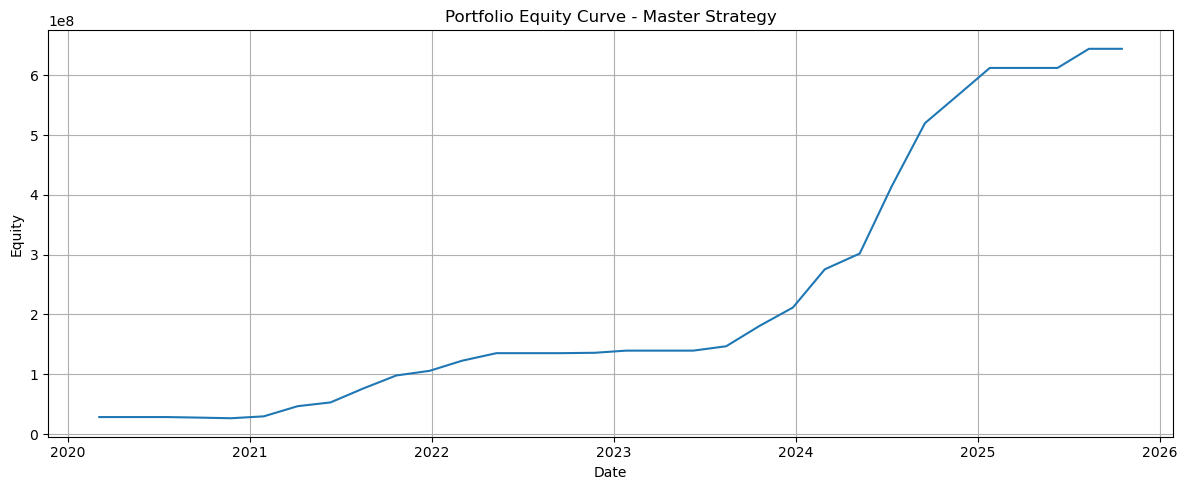

In [ ]:
equity_df = pd.DataFrame(train_master_equity_curve, columns = ["Date", "Equity"])
equity_df = equity_df.sort_values("Date")
equity_df.set_index("Date", inplace = True)

plt.figure(figsize = (12,5))
plt.plot(equity_df.index, equity_df["Equity"])

plt.title("Portfolio Equity Curve - Master Strategy")
plt.xlabel("Date")
plt.ylabel("Equity")

plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
start_val = equity_df["Equity"].iloc[0]
end_val   = equity_df["Equity"].iloc[-1]

years = (equity_df.index[-1] - equity_df.index[0]).days / 365
CAGR = round(100 * ((end_val / start_val) ** (1/ years) - 1), 2)

running_max = equity_df["Equity"].cummax()
drawdown = (equity_df["Equity"] - running_max) / running_max
max_dd = drawdown.min()

print(f"CAGR: {CAGR}%")
print(f"Max Drawdown: {round(100 * max_dd, 1)}%")

CAGR: 74.27%
Max Drawdown: -7.0%


### 2) Low Strategy

In [ ]:
train_equity_low = backtest_low_strategy(df_backtest, 
                                         index_df, 
                                         train_start_date, 
                                         capital = 1_00_00_000)

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/55 [00:00<?, ?bar/s]

KeyboardInterrupt: 

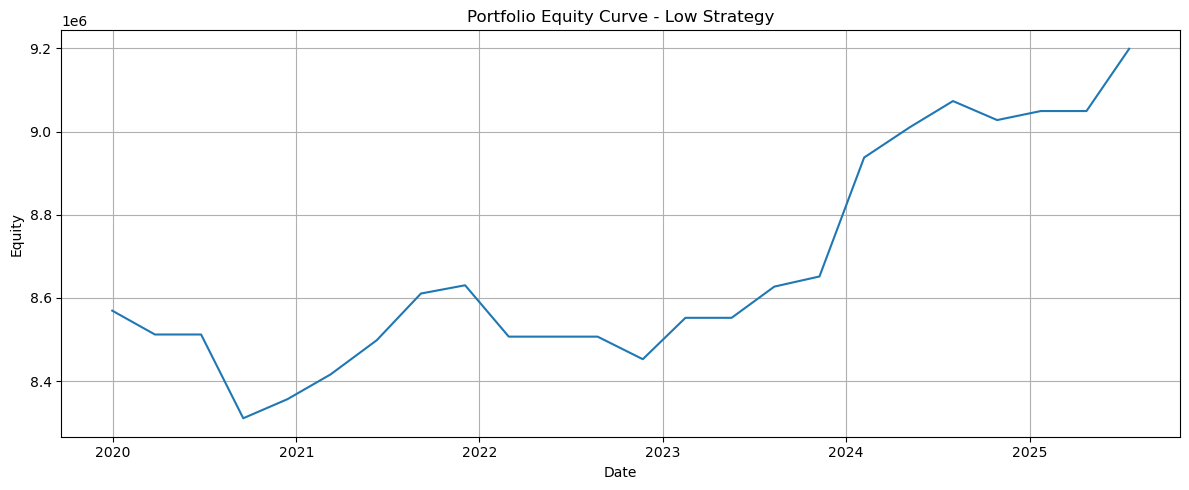

In [ ]:
equity_df = pd.DataFrame(train_equity_low, columns = ["Date", "Equity"])
equity_df = equity_df.sort_values("Date")
equity_df.set_index("Date", inplace = True)

plt.figure(figsize = (12,5))
plt.plot(equity_df.index, equity_df["Equity"])

plt.title("Portfolio Equity Curve - Low Strategy")
plt.xlabel("Date")
plt.ylabel("Equity")

plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
start_val = equity_df["Equity"].iloc[0]
end_val   = equity_df["Equity"].iloc[-1]

years = (equity_df.index[-1] - equity_df.index[0]).days / 365
CAGR = round(100 * ((end_val / start_val) ** (1/ years) - 1), 2)

running_max = equity_df["Equity"].cummax()
drawdown = (equity_df["Equity"] - running_max) / running_max
max_dd = drawdown.min()

print(f"CAGR: {CAGR}%")
print(f"Max Drawdown: {round(100 * max_dd, 1)}%")

CAGR: 1.29%
Max Drawdown: -3.0%


### 3) Medium Strategy

In [ ]:
train_equity_medium = backtest_medium_strategy(df_backtest, 
                                               train_start_date, 
                                               capital = 1_00_00_000)

Market regime suggests no trade for the window: 2012-01-02 - 2012-03-07. Carrying cash forward


Backtest.run:   0%|          | 0/259 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/259 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/259 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/259 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/259 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/259 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/259 [00:00<?, ?bar/s]

Market regime suggests no trade for the window: 2013-10-25 - 2014-01-01. Carrying cash forward
Market regime suggests no trade for the window: 2014-01-01 - 2014-03-06. Carrying cash forward


KeyboardInterrupt: 

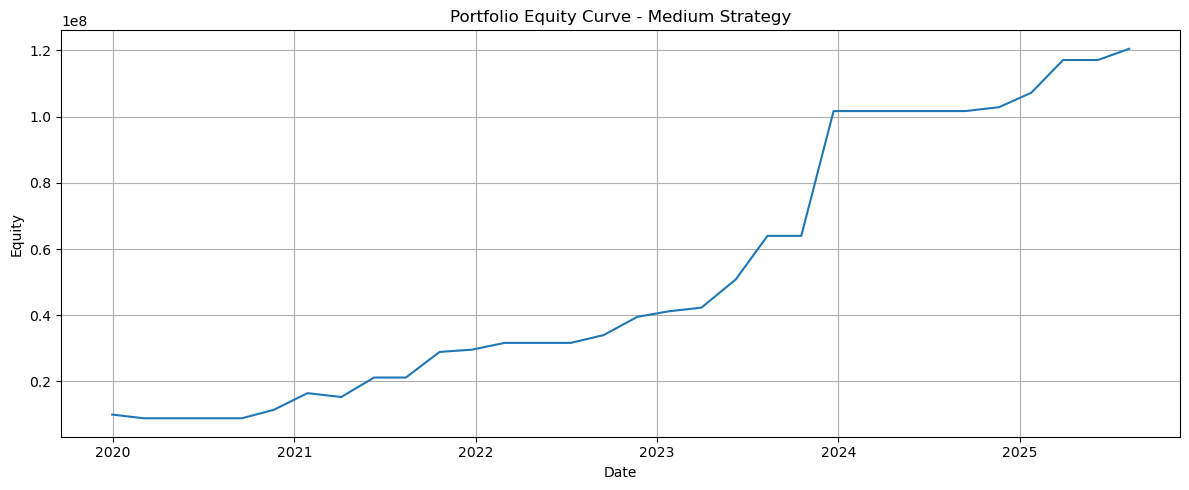

In [ ]:
equity_df = pd.DataFrame(train_equity_medium, columns = ["Date", "Equity"])
equity_df = equity_df.sort_values("Date")
equity_df.set_index("Date", inplace = True)

plt.figure(figsize = (12,5))
plt.plot(equity_df.index, equity_df["Equity"])

plt.title("Portfolio Equity Curve - Medium Strategy")
plt.xlabel("Date")
plt.ylabel("Equity")

plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
start_val = equity_df["Equity"].iloc[0]
end_val   = equity_df["Equity"].iloc[-1]

years = (equity_df.index[-1] - equity_df.index[0]).days / 365
CAGR = round(100 * ((end_val / start_val) ** (1/ years) - 1), 2)

running_max = equity_df["Equity"].cummax()
drawdown = (equity_df["Equity"] - running_max) / running_max
max_dd = drawdown.min()

print(f"CAGR: {CAGR}%")
print(f"Max Drawdown: {round(100 * max_dd, 1)}%")

CAGR: 55.86%
Max Drawdown: -11.0%


### 4) High Strategy

In [ ]:
train_equity_high = backtest_high_strategy(df_backtest, 
                                           index_df, 
                                           train_start_date, 
                                           capital = 1_00_00_000)

Backtest.run:   0%|          | 0/235 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/235 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/235 [00:00<?, ?bar/s]

Market regime suggests no trade for the window: 2020-03-04 - 2020-03-26. Carrying cash forward
No stocks selected post regime filtering for the window: 2020-03-26 - 2020-04-22. Carrying cash forward
No stocks selected post regime filtering for the window: 2020-04-22 - 2020-05-14. Carrying cash forward
Market regime suggests no trade for the window: 2020-05-14 - 2020-06-05. Carrying cash forward
Market regime suggests no trade for the window: 2020-06-05 - 2020-06-26. Carrying cash forward
Market regime suggests no trade for the window: 2020-06-26 - 2020-07-17. Carrying cash forward
Market regime suggests no trade for the window: 2020-07-17 - 2020-08-07. Carrying cash forward
Market regime suggests no trade for the window: 2020-08-07 - 2020-08-28. Carrying cash forward


Backtest.run:   0%|          | 0/235 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/235 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/235 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/235 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/235 [00:00<?, ?bar/s]

KeyboardInterrupt: 

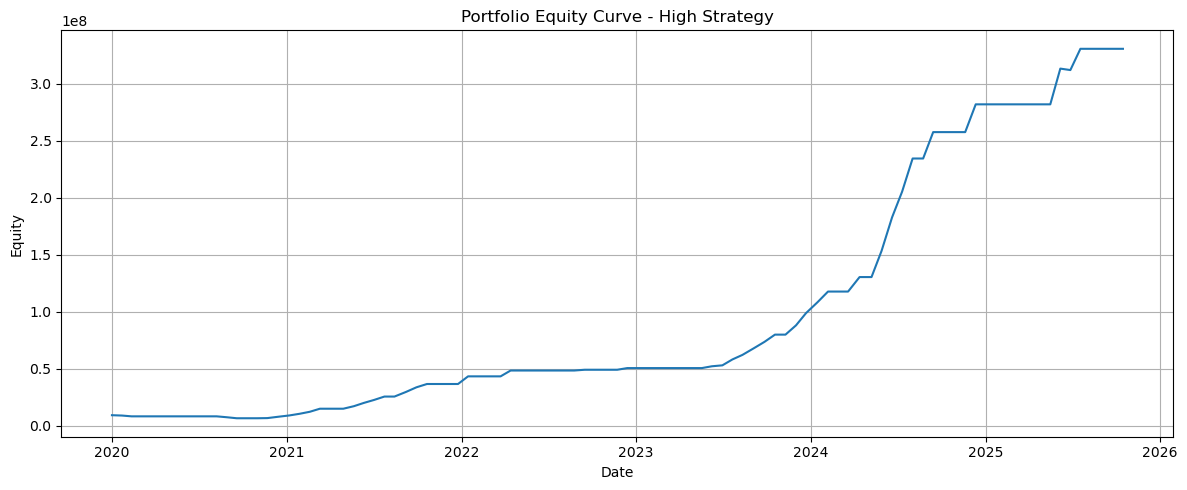

In [ ]:
equity_df = pd.DataFrame(train_equity_high, columns = ["Date", "Equity"])
equity_df = equity_df.sort_values("Date")
equity_df.set_index("Date", inplace = True)

plt.figure(figsize = (12,5))
plt.plot(equity_df.index, equity_df["Equity"])

plt.title("Portfolio Equity Curve - High Strategy")
plt.xlabel("Date")
plt.ylabel("Equity")

plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
start_val = equity_df["Equity"].iloc[0]
end_val   = equity_df["Equity"].iloc[-1]

years = (equity_df.index[-1] - equity_df.index[0]).days / 365
CAGR = round(100 * ((end_val / start_val) ** (1/ years) - 1), 2)

running_max = equity_df["Equity"].cummax()
drawdown = (equity_df["Equity"] - running_max) / running_max
max_dd = drawdown.min()

print(f"CAGR: {CAGR}%")
print(f"Max Drawdown: {round(100 * max_dd, 1)}%")

CAGR: 84.94%
Max Drawdown: -28.5%


## Testing

### 1) Master Strategy

In [ ]:
test_master_equity_curve = run_master_strategy(df = df_backtest,
                                               index_df = index_df,
                                               start_date = test_start_date,
                                               end_date = analysis_end_date,
                                               initial_capital = 3_00_00_000)

In [ ]:
equity_df = pd.DataFrame(test_master_equity_curve, columns = ["Date", "Equity"])
equity_df = equity_df.sort_values("Date")
equity_df.set_index("Date", inplace = True)

plt.figure(figsize = (12,5))
plt.plot(equity_df.index, equity_df["Equity"])

plt.title("Portfolio Equity Curve - Master Strategy")
plt.xlabel("Date")
plt.ylabel("Equity")

plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
start_val = equity_df["Equity"].iloc[0]
end_val   = equity_df["Equity"].iloc[-1]

years = (equity_df.index[-1] - equity_df.index[0]).days / 365
CAGR = round(100 * ((end_val / start_val) ** (1/ years) - 1), 2)

running_max = equity_df["Equity"].cummax()
drawdown = (equity_df["Equity"] - running_max) / running_max
max_dd = drawdown.min()

print(f"CAGR: {CAGR}%")
print(f"Max Drawdown: {round(100 * max_dd, 1)}%")

### 2) Low Strategy

In [ ]:
test_low_equity_low = backtest_low_strategy(df_backtest, 
                                            index_df, 
                                            test_start_date, 
                                            1_00_00_000)

NameError: name 'backtest_low_strategy' is not defined

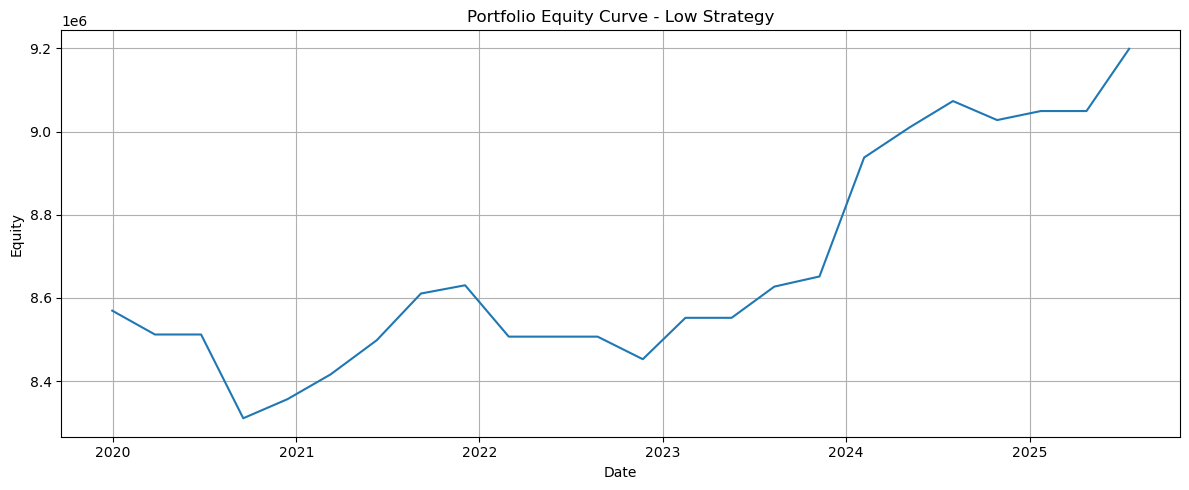

In [ ]:
equity_df = pd.DataFrame(test_low_equity_low, columns = ["Date", "Equity"])
equity_df = equity_df.sort_values("Date")
equity_df.set_index("Date", inplace = True)

plt.figure(figsize = (12,5))
plt.plot(equity_df.index, equity_df["Equity"])
plt.title("Portfolio Equity Curve - Low Strategy")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
start_val = equity_df["Equity"].iloc[0]
end_val   = equity_df["Equity"].iloc[-1]

years = (equity_df.index[-1] - equity_df.index[0]).days / 365
CAGR = round(100 * ((end_val / start_val) ** (1/ years) - 1), 2)

running_max = equity_df["Equity"].cummax()
drawdown = (equity_df["Equity"] - running_max) / running_max
max_dd = drawdown.min()

print(f"CAGR: {CAGR}%")
print(f"Max Drawdown: {round(100 * max_dd, 1)}%")

CAGR: 1.29%
Max Drawdown: -3.0%


### 3) Medium Strategy

In [ ]:
test_equity_medium = backtest_medium_strategy(df_backtest, 
                                              test_start_date, 
                                              capital = 1_00_00_000)

No stocks selected post regime filtering for the window: 2020-01-01 - 2020-03-04. Carrying cash forward


Backtest.run:   0%|          | 0/219 [00:00<?, ?bar/s]

Market regime suggests no trade for the window: 2020-05-14 - 2020-07-17. Carrying cash forward
No stocks selected post regime filtering for the window: 2020-07-17 - 2020-09-18. Carrying cash forward
Market regime suggests no trade for the window: 2020-09-18 - 2020-11-23. Carrying cash forward


Backtest.run:   0%|          | 0/219 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/219 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/219 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/219 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/219 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/219 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/219 [00:00<?, ?bar/s]

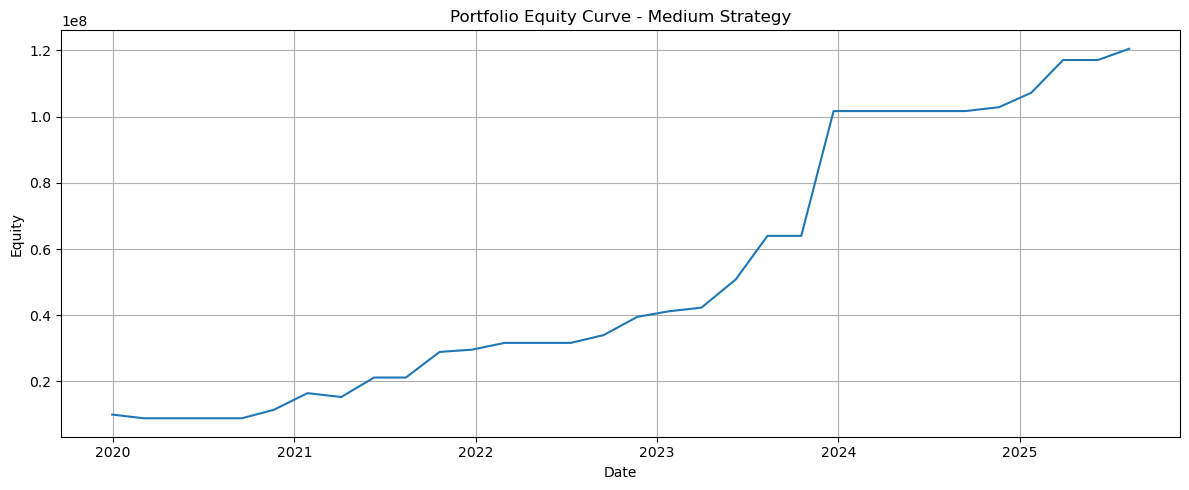

In [ ]:
equity_df = pd.DataFrame(test_equity_medium, columns = ["Date", "Equity"])
equity_df = equity_df.sort_values("Date")
equity_df.set_index("Date", inplace = True)

plt.figure(figsize = (12,5))
plt.plot(equity_df.index, equity_df["Equity"])
plt.title("Portfolio Equity Curve - Medium Strategy")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
start_val = equity_df["Equity"].iloc[0]
end_val   = equity_df["Equity"].iloc[-1]

years = (equity_df.index[-1] - equity_df.index[0]).days / 365
CAGR = round(100 * ((end_val / start_val) ** (1/ years) - 1), 2)

running_max = equity_df["Equity"].cummax()
drawdown = (equity_df["Equity"] - running_max) / running_max
max_dd = drawdown.min()

print(f"CAGR: {CAGR}%")
print(f"Max Drawdown: {round(100 * max_dd, 1)}%")

CAGR: 55.86%
Max Drawdown: -11.0%


### 4) High Strategy

In [ ]:
test_equity_high = backtest_high_strategy(df_backtest, 
                                          index_df, 
                                          test_start_date, 
                                          capital = 1_00_00_000)

Backtest.run:   0%|          | 0/195 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/195 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/195 [00:00<?, ?bar/s]

Market regime suggests no trade for the window: 2020-03-04 - 2020-03-26. Carrying cash forward
No stocks selected post regime filtering for the window: 2020-03-26 - 2020-04-22. Carrying cash forward
No stocks selected post regime filtering for the window: 2020-04-22 - 2020-05-14. Carrying cash forward
Market regime suggests no trade for the window: 2020-05-14 - 2020-06-05. Carrying cash forward
Market regime suggests no trade for the window: 2020-06-05 - 2020-06-26. Carrying cash forward
Market regime suggests no trade for the window: 2020-06-26 - 2020-07-17. Carrying cash forward
Market regime suggests no trade for the window: 2020-07-17 - 2020-08-07. Carrying cash forward
Market regime suggests no trade for the window: 2020-08-07 - 2020-08-28. Carrying cash forward


Backtest.run:   0%|          | 0/195 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/195 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/195 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/195 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/195 [00:00<?, ?bar/s]

Market regime suggests no trade for the window: 2025-08-11 - 2025-09-03. Carrying cash forward
Market regime suggests no trade for the window: 2025-09-03 - 2025-09-24. Carrying cash forward
Market regime suggests no trade for the window: 2025-09-24 - 2025-10-16. Carrying cash forward
Market regime suggests no trade for the window: 2025-10-16 - 2025-11-10. Carrying cash forward


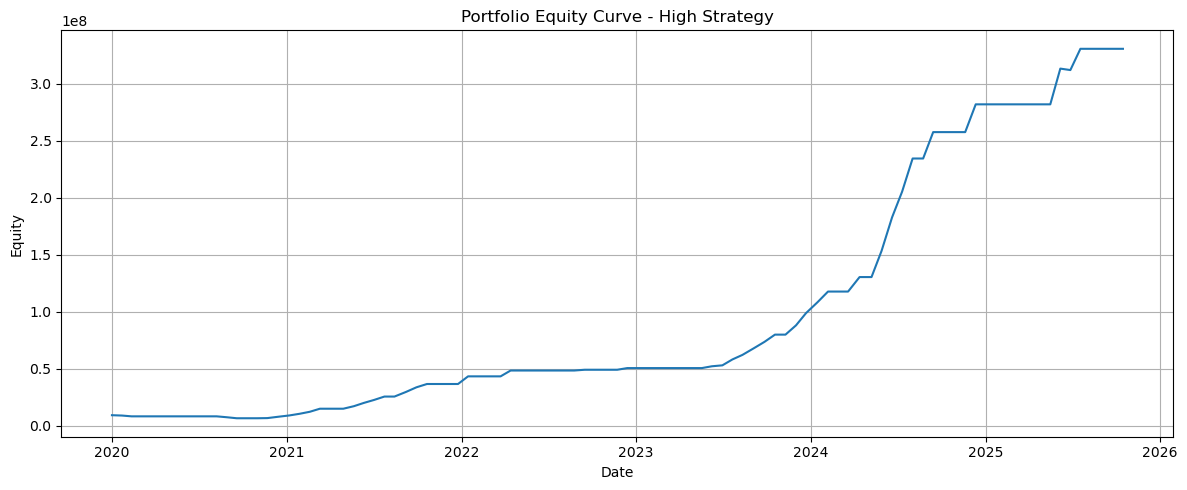

In [ ]:
equity_df = pd.DataFrame(test_equity_high, columns = ["Date", "Equity"])
equity_df = equity_df.sort_values("Date")
equity_df.set_index("Date", inplace = True)

plt.figure(figsize = (12,5))
plt.plot(equity_df.index, equity_df["Equity"])
plt.title("Portfolio Equity Curve - High Strategy")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
start_val = equity_df["Equity"].iloc[0]
end_val   = equity_df["Equity"].iloc[-1]

years = (equity_df.index[-1] - equity_df.index[0]).days / 365
CAGR = round(100 * ((end_val / start_val) ** (1/ years) - 1), 2)

running_max = equity_df["Equity"].cummax()
drawdown = (equity_df["Equity"] - running_max) / running_max
max_dd = drawdown.min()

print(f"CAGR: {CAGR}%")
print(f"Max Drawdown: {round(100 * max_dd, 1)}%")

CAGR: 84.94%
Max Drawdown: -28.5%
